# UK E-Commerce: Sales, Products and Customer Analysis

**Tomisin Obijole | BuildLabs Internship | Task 1: Exploratory Data Analysis**

## Business objective

Analyze transaction-level records to understand sales performance, product 
demand, customer concentration, geographic markets, time patterns, and 
unusual entries. The findings should inform questions for inventory,
customer retention, and commercial planning.

## Scope and definitions

- Each row is an invoice line, not necessarily a complete order.
- **Positive Sales** include invoice lines with `Quantity` > 0 and `UnitPrice` > 0. Returns, cancellations, and negative-price adjustments are inspected separately and excluded from this measure.
- **Merchandise analysis** additionally excludes identifiable postage, fees, and accounting entries.
- Customer-specific results include only rows with a CustomerID.
- This is descriptive analysis. Observed patterns do not establish causes, profit, or future demand.

## Dataset and grain

Source: [Online Retail dataset](https://www.kaggle.com/datasets/carrie1/ecommerce-data).

| `Field` | Meaning in this analysis |
|---|---|
| `InvoiceNo` | Invoice identifier; retain as text because prefixes may matter |
| `StockCode` | Product or transaction-entry code |
| `Description` | Supplied item or entry description; can be missing or inconsistent | 
| `Quantity` | Units on an invoice line; negative values require separate review |
| `InvoiceDate` |Recorded invoice date and time |
| `UnitPrice` | Recorded price per unit |
| `CustomerID` | Customer identifier; may be missing |
| `Country` | Country recorded for the transaction |

**Unit of observation:** an invoice line. Distinct 'InvoiceNo' values are used as an order proxy, subject to the source data's limitations.

## Running this notebook

Install pandas, NumPy, Matplotlib, Seaborn, and Jupyter.
Download the source CSV from the dataset link above and place it beside
this notebook as `data.csv`.

Run all cells from top to bottom. The final cell writes cleaned analytical
tables and summaries to the Task 2 folder.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_PATH = Path("data.csv")
df = pd.read_csv(
    DATA_PATH,
    encoding="latin-1",
    dtype={"InvoiceNo": "string", "StockCode": "string", "Country": "string"},
)

print(f"Raw invoice lines: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Raw invoice lines: 541,909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df.info()
display(df.describe(include="all").T)

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (100 * df.isna().mean()).round(2),
    "distinct": df.nunique(dropna=True),
})
display(quality)

print(f"Exact duplicate rows: {df.duplicated().sum():,}")
display(df[df.duplicated(keep=False)].head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  string 
 1   StockCode    541909 non-null  string 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  string 
dtypes: float64(2), int64(1), object(2), string(3)
memory usage: 33.1+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,dtype,missing,missing_pct,distinct
InvoiceNo,string,0,0.00,25900
StockCode,string,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,object,0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,string,0,0.00,38


Exact duplicate rows: 5,268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


_The output establishes 1,454 missing descriptions, 135,080 missing Customer IDs, and 5,268 exact duplicate rows. The numeric summary also shows quantity as low as -80,995 and prices as low as -£11,062.06. Those warrant an audit; the minima alone do not tell us the business meaning of every record._

## Data-quality decisions

1. Remove exact duplicate rows for this analysis to avoid counting identical
   invoice lines twice. Because no separate line-item ID exists, this is an
   explicit analytical assumption.
2. Preserve invoice numbers as strings; letter prefixes may identify special
   entries.
3. Parse invoice dates with the observed month/day/year format.
4. Separate negative-quantity and negative-price records from positive sales.
   This analysis does not calculate net sales after returns.
5. Keep missing CustomerIDs for total sales, but exclude them from
   customer-level analysis.
6. Keep missing descriptions in total sales; exclude them from named-product
   rankings.
7. Classify non-merchandise entries before ranking products.

In [3]:
base = df.drop_duplicates().copy()
base["InvoiceDate"] = pd.to_datetime(
    base["InvoiceDate"], format="%m/%d/%Y %H:%M", errors="coerce"
)
base["InvoiceNo"] = base["InvoiceNo"].astype("string").str.strip()
base["StockCode"] = base["StockCode"].astype("string").str.strip()

base["Description_clean"] = (
    base["Description"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.upper()
)
base["Country"] = base["Country"].str.strip()

audit = pd.Series({
    "Raw invoice lines": len(df),
    "Exact duplicates removed": df.duplicated().sum(),
    "Lines after deduplication": len(base),
    "Unparseable dates": base["InvoiceDate"].isna().sum(),
    "Negative quantity lines": (base["Quantity"] < 0).sum(),
    "Negative price lines": (base["UnitPrice"] < 0).sum(),
    "Zero quantity lines": (base["Quantity"] == 0).sum(),
    "Zero price lines": (base["UnitPrice"] == 0).sum(),
    "Missing CustomerID lines": base["CustomerID"].isna().sum(),
    "Missing descriptions": base["Description_clean"].isna().sum(),
    "Invoice Numbers starting with C": base["InvoiceNo"].str.startswith("C", na=False).sum(),
})
display(audit.to_frame("count"))

,count
Raw invoice lines,541909
Exact duplicates removed,5268
Lines after deduplication,536641
Unparseable dates,0
Negative quantity lines,10587
Negative price lines,2
Zero quantity lines,0
Zero price lines,2510
Missing CustomerID lines,135037
Missing descriptions,1454


In [4]:
cols = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "UnitPrice", "CustomerID", "Country"
]

display(base.loc[base["Quantity"] < 0, cols].head(10))
display(base.loc[base["UnitPrice"] < 0, cols])
display(base.loc[base["UnitPrice"] == 0, cols].head(20))
display(base.loc[base["Description_clean"].isna(), cols].head(10))

special_terms = r"POSTAGE|POST|FEE|CHARGE|BAD DEBT|ADJUST"
display(
    base.loc[
        base["Description_clean"].str.contains(
            special_terms, regex=True, na=False
        ),
        cols,
    ].drop_duplicates(subset=["StockCode", "Description"]).head(40)
)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25,17897.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,18.00,12583.0,France
53,536373,37370,RETRO COFFEE MUGS ASSORTED,6,1.06,17850.0,United Kingdom
1100,536526,21135,VICTORIAN METAL POSTCARD SPRING,16,1.69,14001.0,United Kingdom
1206,536530,21662,VINTAGE GLASS COFFEE CADDY,1,5.95,17905.0,United Kingdom
1546,536544,22300,COFFEE MUG DOG + BALL DESIGN,1,5.06,NaN,United Kingdom
1547,536544,22301,COFFEE MUG CAT + BIRD DESIGN,2,5.06,NaN,United Kingdom
1765,536544,85015,SET OF 12 VINTAGE POSTCARD SET,1,2.51,NaN,United Kingdom
1814,536544,DOT,DOTCOM POSTAGE,1,569.77,NaN,United Kingdom
1922,536544,21216,"SET 3 RETROSPOT TEA,COFFEE,SUGAR",1,11.02,NaN,United Kingdom
2444,536591,21398,RED POLKADOT COFFEE MUG,1,2.10,14606.0,United Kingdom


In [5]:
sales = base.loc[
    base["InvoiceDate"].notna()
    & base["Quantity"].gt(0)
    & base["UnitPrice"].gt(0)
].copy()

sales["LineSales"] = sales["Quantity"] * sales["UnitPrice"]
sales["YearMonth"] = sales["InvoiceDate"].dt.to_period("M")
sales["OrderDate"] = sales["InvoiceDate"].dt.normalize()
sales["Weekday"] = sales["InvoiceDate"].dt.day_name()
sales["Hour"] = sales["InvoiceDate"].dt.hour

# Separate identifiable charges/accounting entries and ambiguous manual
# entries from named-merchandise analysis. Retain them in `sales`.
non_merch_codes = {
    "DOT", "POST", "BANK CHARGES", "AMAZONFEE", "B", "M"
}
non_merch_descriptions = {
    "DOTCOM POSTAGE",
    "POSTAGE",
    "AMAZON FEE",
    "BANK CHARGES",
    "ADJUST BAD DEBT",
    "MANUAL",
}

sales["IsNonMerchandise"] = (
    sales["StockCode"].str.upper().isin(non_merch_codes)
    | sales["Description_clean"].isin(non_merch_descriptions)
)

merchandise = sales.loc[
    ~sales["IsNonMerchandise"]
    & sales["Description_clean"].notna()
].copy()

identified = sales.loc[sales["CustomerID"].notna()].copy()

display(pd.Series({
    "Positive-sales lines": len(sales),
    "Positive-sales value": sales["LineSales"].sum(),
    "Identified-customer sales value": identified["LineSales"].sum(),
    "Unidentified-customer sales value":
        sales.loc[sales["CustomerID"].isna(), "LineSales"].sum(),
    "Non-merchandise lines flagged": sales["IsNonMerchandise"].sum(),
    "Missing-description sales value":
        sales.loc[sales["Description_clean"].isna(), "LineSales"].sum(),
    "Named merchandise lines": len(merchandise),
}).to_frame("value"))

,value
Positive-sales lines,5.248780e+05
Positive-sales value,1.064211e+07
Identified-customer sales value,8.887209e+06
Unidentified-customer sales value,1.754902e+06
Non-merchandise lines flagged,2.164000e+03
Missing-description sales value,0.000000e+00
Named merchandise lines,5.227140e+05


### Merchandise classification

Postage, Amazon fees, bank charges, bad-debt adjustments, and entries labelled
MANUAL are excluded from named-merchandise analysis.

MANUAL entries are excluded because their descriptions do not identify a
specific product. This classification does not establish that the entries
are invalid or that they have no commercial value.

These entries remain in the overall positive-value table. Consequently,
the overall recorded value and named-merchandise sales answer different
questions and should not be used interchangeably.

### Cleaning outcome

The raw dataset contained 541,909 invoice lines. Removing 5,268 exact duplicate
rows left 536,641 lines.

Requiring a valid invoice date, positive quantity, and positive unit price
produced 524,878 analytical lines: 11,763 fewer than the deduplicated table.
All invoice dates parsed successfully.

The audit identified 10,587 negative-quantity lines, two negative-price lines,
and 2,510 zero-price lines. These categories can overlap, so their counts
must not simply be added together.

Rows without CustomerID remain in the overall analysis but are excluded
from customer-level metrics. Identifiable charges, accounting adjustments,
and ambiguous manual entries are separately classified for merchandise
analysis.

The resulting value excludes negative entries and is not net revenue
after returns or profit.

In [6]:
snapshot = pd.Series({
    "First invoice": sales["InvoiceDate"].min(),
    "Last invoice": sales["InvoiceDate"].max(),
    "Invoice lines": len(sales),
    "Distinct invoices": sales["InvoiceNo"].nunique(),
    "Identified customers": identified["CustomerID"].nunique(),
    "Distinct stock codes in merchandise": merchandise["StockCode"].nunique(),
    "Countries": sales["Country"].nunique(),
    "Units on positive-sales lines": sales["Quantity"].sum(),
    "Positive-sales value (£)": sales["LineSales"].sum(),
    "Sales per invoice proxy (£)":
        sales["LineSales"].sum() / sales["InvoiceNo"].nunique(),
})
display(snapshot.to_frame("value"))

assert sales["Quantity"].gt(0).all()
assert sales["UnitPrice"].gt(0).all()
assert sales["InvoiceDate"].notna().all()
assert len(merchandise) <= len(sales)

,value
First invoice,2010-12-01 08:26:00
Last invoice,2011-12-09 12:50:00
Invoice lines,524878
Distinct invoices,19960
Identified customers,4338
Distinct stock codes in merchandise,3915
Countries,38
Units on positive-sales lines,5572420
Positive-sales value (£),10642110.804
Sales per invoice proxy (£),533.171884


## Exploratory distributions

Quantity and unit price can be highly skewed. The plots below show values
through the 99th percentile so typical invoice lines remain visible. Records
above that cutoff remain in the tables and are investigated separately.

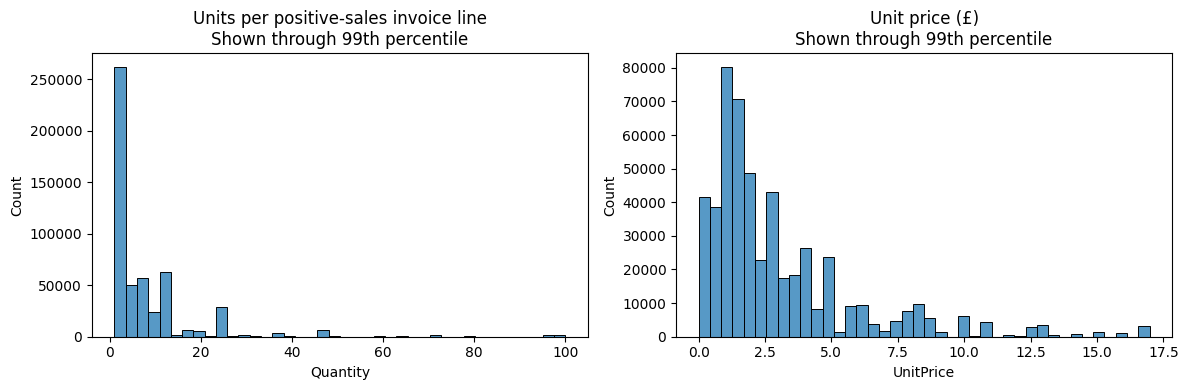

,count,mean,std,min,50%,90%,95%,99%,99.9%,max
Quantity,524878.0,10.616600,156.280031,1.000,4.00,24.00,30.00,100.00,456.00000,80995.00
UnitPrice,524878.0,3.922573,36.093028,0.001,2.08,7.95,9.95,16.98,165.02460,13541.33
LineSales,524878.0,20.275399,271.693566,0.001,9.92,33.00,59.80,183.60,841.21059,168469.60


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, column, title in [
    (axes[0], "Quantity", "Units per positive-sales invoice line"),
    (axes[1], "UnitPrice", "Unit price (£)"),
]:
    cutoff = sales[column].quantile(0.99)
    sns.histplot(
        sales.loc[sales[column] <= cutoff, column],
        bins=40, ax=ax
    )
    ax.set_title(f"{title}\nShown through 99th percentile")
    ax.set_xlabel(column)

plt.tight_layout()
plt.show()

display(sales[["Quantity", "UnitPrice", "LineSales"]].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
).T)

### Distribution findings

The median invoice line contains four units, compared with a mean of 10.62.
The difference indicates a right-skewed quantity distribution: a relatively
small number of large lines raise the average.

Median unit price is £2.08, while the 99th percentile is £16.98.
The very largest prices include postage, fees, accounting adjustments,
and manual entries, so they should not be interpreted automatically as
expensive merchandise.

The displayed histograms are restricted to values through the 99th percentile
for readability. The underlying analytical tables retain the larger values.

## Q1. How much positive-sales value was recorded?

Report the value for the full positive-sales table and separately the value
attributable to identified customers. This is not net sales after returns,
and it includes identifiable service/accounting entries until the
merchandise-only view is selected.

In [8]:
print(f"Recorded positive line value: £{sales['LineSales'].sum():,.2f}")
print(f"Identified-customer positive sales: "
      f"£{identified['LineSales'].sum():,.2f}")
print(f"Named merchandise positive sales: "
      f"£{merchandise['LineSales'].sum():,.2f}")

Recorded positive line value: £10,642,110.80
Identified-customer positive sales: £8,887,208.89
Named merchandise positive sales: £10,255,019.18


### Sales-value interpretation

Recorded positive line value totals £10,642,110.80. Of this, £8,887,208.89
is associated with identified customers and £1,754,901.92 has no CustomerID.

Approximately 16.5% of recorded positive value therefore cannot be assigned
to an identified customer. Customer rankings and concentration measures
describe the identified subset, rather than the complete business.

The overall figure includes separately classified charges and accounting
entries. Named-merchandise sales are reported separately after applying
the classification rules above.

## Q2–Q3. Which merchandise products lead by sales value and units?

Group on `StockCode`, the supplied item identifier, and show a representative
cleaned description. A description alone is unreliable: the original notebook
shows the same FRENCH PAISLEY CUSHION COVER under two spacing variants.
Postage and accounting entries are excluded from this merchandise ranking.

,StockCode,Description,Sales,Units,Invoices
1310,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2465,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3407,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104462.75,37641,2198
2670,47566,PARTY BUNTING,99445.23,18283,1685
3387,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2020,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
1942,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
1006,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
3194,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
2845,79321,CHILLI LIGHTS,54096.36,10302,661


,StockCode,Description,Sales,Units,Invoices
2465,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2020,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
1109,22197,POPCORN HOLDER,51334.47,56898,1392
2909,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13814.01,54951,535
3387,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
3407,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104462.75,37641,2198
439,21212,PACK OF 72 RETROSPOT CAKE CASES,21246.45,36396,1320
3194,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
1942,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
1374,22492,MINI PAINT SET VINTAGE,16937.82,26633,380


StockCode
23196     4
23236     4
17107D    3
23231     3
23366     3
22937     3
23131     3
22776     3
23209     3
23126     3
Name: Description_clean, dtype: int64

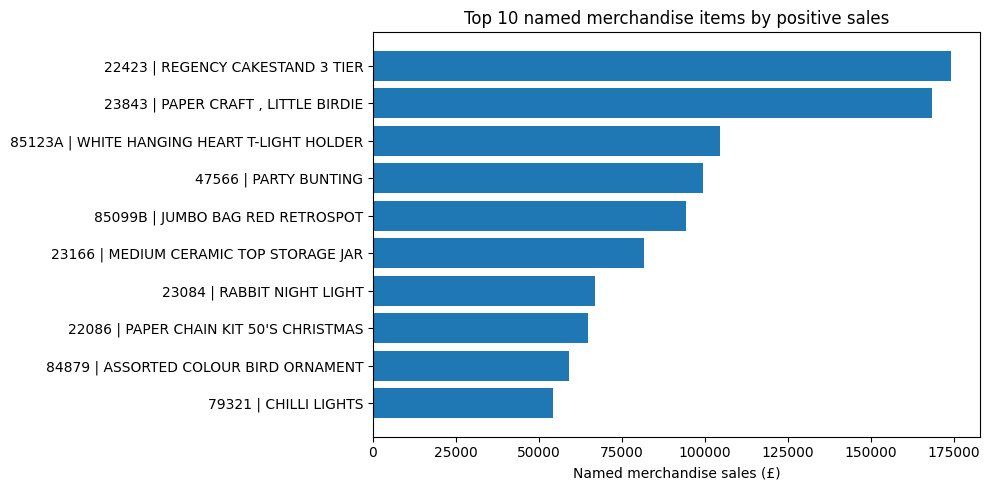

In [9]:
products = (
    merchandise.groupby("StockCode", dropna=False)
    .agg(
        Description=("Description_clean", lambda s: s.mode().iat[0]),
        Sales=("LineSales", "sum"),
        Units=("Quantity", "sum"),
        Invoices=("InvoiceNo", "nunique"),
    )
    .reset_index()
)

display(products.nlargest(10, "Sales"))
display(products.nlargest(10, "Units"))

# Investigate item codes associated with several cleaned descriptions.
description_variants = (
    merchandise.groupby("StockCode")["Description_clean"]
    .nunique().sort_values(ascending=False)
)
display(description_variants.head(10))

top_products = products.nlargest(10, "Sales").sort_values("Sales")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    top_products["StockCode"] + " | " + top_products["Description"],
    top_products["Sales"],
)
ax.set_title("Top 10 named merchandise items by positive sales")
ax.set_xlabel("Named merchandise sales (£)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Product findings

REGENCY CAKESTAND 3 TIER records £174,156.54 across 1,988 positive-sales
invoices, providing evidence of recurring recorded demand.

PAPER CRAFT, LITTLE BIRDIE records £168,469.60 and 80,995 units from a
single invoice. Its high ranking reflects one exceptionally large line,
so it should not be interpreted as consistently strong demand.

Product rankings use StockCode as the item identifier. The displayed
description is a representative label, because some stock codes have
multiple descriptions.

## Q4. Which products appear rarely or generate little sales value?

These are three separate exploratory measures: distinct invoices, sales
value, and units. Thresholds below are screening rules for this notebook;
they do not establish whether a product is unprofitable or should be removed.

In [10]:
products["Rare_5_Invoices"] = products["Invoices"] <= 5
products["Low_Sales_100"] = products["Sales"] < 100
products["Low_Units_50"] = products["Units"] < 50

screen = products[
    products[[
        "Rare_5_Invoices", "Low_Sales_100", "Low_Units_50"
    ]].all(axis=1)
].sort_values(["Sales", "Invoices"])

display(pd.Series({
    "Rare (≤5 invoices)": products["Rare_5_Invoices"].sum(),
    "Under £100 sales": products["Low_Sales_100"].sum(),
    "Under 50 units": products["Low_Units_50"].sum(),
    "Meet all three screens": len(screen),
}).to_frame("products"))
display(screen.head(15))

,products
Rare (≤5 invoices),514
Under £100 sales,875
Under 50 units,933
Meet all three screens,467


,StockCode,Description,Sales,Units,Invoices,Rare_5_Invoices,Low_Sales_100,Low_Units_50
3908,PADS,PADS TO MATCH ALL CUSHIONS,0.003,3,3,True,True,True
2923,84227,HEN HOUSE W CHICK IN NEST,0.420,1,1,True,True,True
2714,51014c,"FEATHER PEN,COAL BLACK",0.830,1,1,True,True,True
476,21268,VINTAGE BLUE TINSEL REEL,0.840,2,1,True,True,True
3666,90084,PINK CRYSTAL GUITAR PHONE CHARM,0.850,1,1,True,True,True
2916,84201C,HAPPY BIRTHDAY CARD TEDDY/CAKE,0.950,5,1,True,True,True
2918,84206B,CAT WITH SUNGLASSES BLANK CARD,0.950,5,1,True,True,True
3275,84990,60 GOLD AND SILVER FAIRY CAKE CASES,1.100,2,2,True,True,True
311,21009,ETCHED GLASS STAR TREE DECORATION,1.250,1,1,True,True,True
2481,35597A,DUSTY PINK CHRISTMAS TREE 30CM,1.250,1,1,True,True,True


### Low-sales screening interpretation

The table identifies items that appear in few invoices, generate little
recorded sales value, or sell few units. These measures describe different
aspects of performance.

An item can be rare but generate substantial sales value, as illustrated by
the single large PAPER CRAFT, LITTLE BIRDIE invoice. Conversely, low recorded
sales may reflect a new product, limited availability, or a specialist item.

Products meeting all three screens warrant investigation. Discontinuation
would require additional evidence on margins, stock availability, product
age, and strategic importance.

## Q5. Who are the highest-spending identified customers?

Customer rankings and concentration percentages use only sales associated
with a CustomerID. The unassigned sales amount is reported separately and
is not silently allocated to a customer.

In [11]:
customers = (
    identified.groupby("CustomerID")
    .agg(
        Sales=("LineSales", "sum"),
        Invoices=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        LastPurchase=("InvoiceDate", "max"),
    )
    .sort_values("Sales", ascending=False)
)
customers["SalesPerInvoice"] = customers["Sales"] / customers["Invoices"]

display(customers.head(10))
print(f"Top five share of identified-customer sales: "
      f"{customers.head(5)['Sales'].sum() / customers['Sales'].sum():.1%}")

,Sales,Invoices,Units,LastPurchase,SalesPerInvoice
CustomerID,,,,,
14646.0,280206.02,73,196915,2011-12-08 12:12:00,3838.438630
18102.0,259657.30,60,64124,2011-12-09 11:50:00,4327.621667
17450.0,194390.79,46,69973,2011-12-01 13:29:00,4225.886739
16446.0,168472.50,2,80997,2011-12-09 09:15:00,84236.250000
14911.0,143711.17,201,80240,2011-12-08 15:54:00,714.980945
12415.0,124914.53,21,77374,2011-11-15 14:22:00,5948.310952
14156.0,117210.08,55,57768,2011-11-30 10:54:00,2131.092364
17511.0,91062.38,31,64549,2011-12-07 10:12:00,2937.496129
16029.0,80850.84,63,40108,2011-11-01 10:27:00,1283.346667


Top five share of identified-customer sales: 11.8%


Top 10% of identified customers: 61.5% of identified-customer sales
Customers needed to reach at least 80%: 1,130 (26.0%)


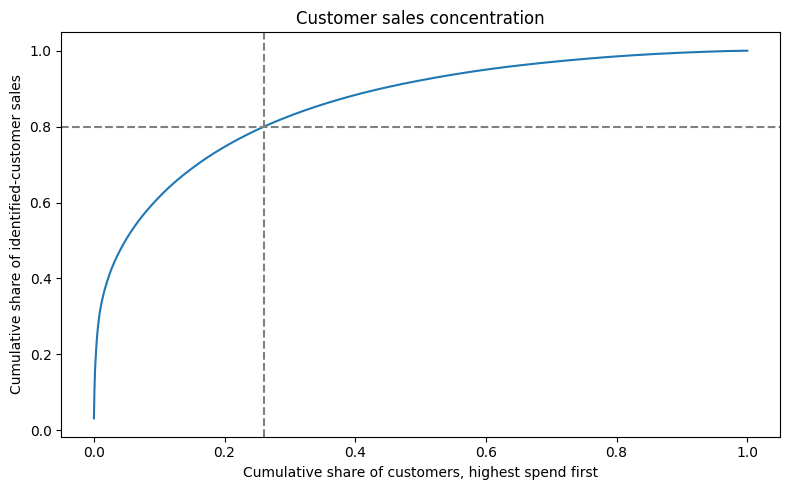

In [12]:
ranked = customers.reset_index().copy()
ranked["CustomerRank"] = np.arange(1, len(ranked) + 1)
ranked["CustomerShare"] = ranked["CustomerRank"] / len(ranked)
ranked["CumulativeSalesShare"] = (
    ranked["Sales"].cumsum() / ranked["Sales"].sum()
)

first_at_80 = ranked.loc[
    ranked["CumulativeSalesShare"] >= 0.80
].iloc[0]
top_10pct_n = int(np.ceil(len(ranked) * 0.10))

print(f"Top 10% of identified customers: "
      f"{ranked.head(top_10pct_n)['Sales'].sum() / ranked['Sales'].sum():.1%} "
      f"of identified-customer sales")
print(f"Customers needed to reach at least 80%: "
      f"{int(first_at_80['CustomerRank']):,} "
      f"({first_at_80['CustomerShare']:.1%})")

plt.figure(figsize=(8, 5))
plt.plot(ranked["CustomerShare"], ranked["CumulativeSalesShare"])
plt.axhline(0.8, linestyle="--", color="gray")
plt.axvline(first_at_80["CustomerShare"], linestyle="--", color="gray")
plt.xlabel("Cumulative share of customers, highest spend first")
plt.ylabel("Cumulative share of identified-customer sales")
plt.title("Customer sales concentration")
plt.tight_layout()
plt.show()

### Customer concentration

The top five identified customers contribute approximately 11.8% of
identified-customer recorded positive value. The highest-spending tenth
contributes 61.5%, and 1,130 customers—approximately 26.0% of the identified
customer base—are needed to reach at least 80%.

The largest individual account represents approximately 3.2% of
identified-customer value. Concentration therefore exists across a broader
high-value group, rather than being dominated by one customer.

These results describe identified customers only. They also include large
positive lines whose possible reversals require separate investigation.

## Q6. How did sales change over time?

Compare monthly sales with invoice count and sales per invoice. December 2011
contains only data through December 9, so it is marked as a partial month.
The available period spans just over one year; it cannot establish a
repeatable annual seasonal pattern.

,Sales,Invoices,Units,IdentifiedCustomers,SalesPerInvoice,SalesGrowthPct,PeriodStatus
YearMonth,,,,,,,
2010-12,821452.730,1559,358019,885,526.910026,NaN,Full or near-full month
2011-01,689811.610,1086,387099,741,635.185645,-16.025404,Full or near-full month
2011-02,522545.560,1100,282934,758,475.041418,-24.248077,Full or near-full month
2011-03,716215.260,1454,376599,974,492.582710,37.062740,Full or near-full month
2011-04,536968.491,1246,307953,856,430.953845,-25.026941,Full or near-full month
2011-05,769296.610,1681,395001,1056,457.642243,43.266620,Full or near-full month
2011-06,760547.010,1533,388511,991,496.116771,-1.137351,Full or near-full month
2011-07,718076.121,1475,399693,949,486.831268,-5.584256,Full or near-full month
2011-08,757841.380,1361,421020,935,556.826877,5.537750,Full or near-full month


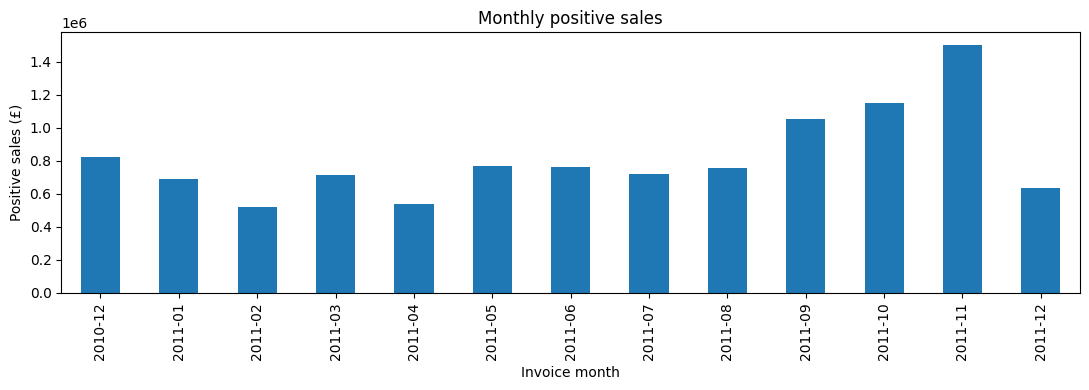

,Sales,Invoices
OrderDate,,
2011-11-29,72384.82,135
2011-11-30,60025.57,108
2011-12-01,52068.63,121
2011-12-02,57476.48,120
2011-12-04,24477.47,66
2011-12-05,88620.84,127
2011-12-06,56558.83,115
2011-12-07,75315.55,106
2011-12-08,82371.55,120


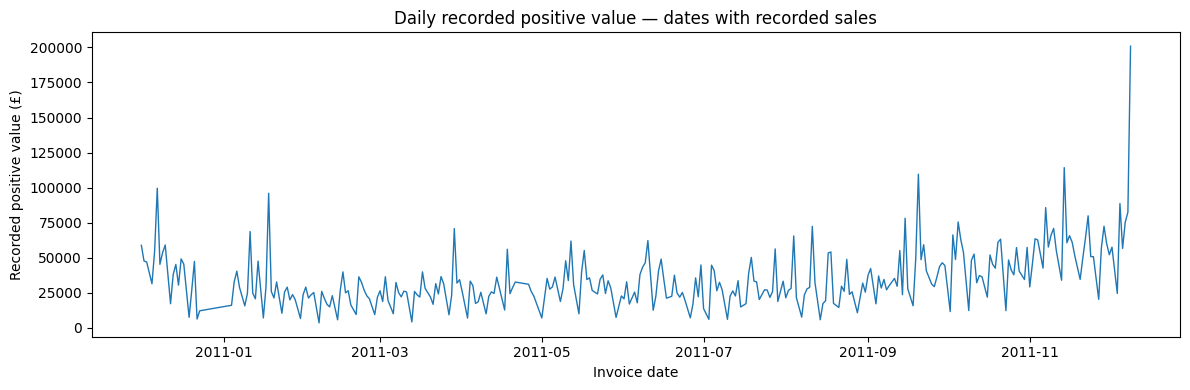

In [13]:
monthly = (
    sales.groupby("YearMonth")
    .agg(
        Sales=("LineSales", "sum"),
        Invoices=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        IdentifiedCustomers=("CustomerID", "nunique"),
    )
)
monthly["SalesPerInvoice"] = monthly["Sales"] / monthly["Invoices"]
monthly["SalesGrowthPct"] = monthly["Sales"].pct_change() * 100
monthly["PeriodStatus"] = "Full or near-full month"
monthly.loc[
    monthly.index == pd.Period("2011-12"),
    "SalesGrowthPct"
] = np.nan

display(monthly)

ax = monthly["Sales"].plot(
    kind="bar", figsize=(11, 4), title="Monthly positive sales"
)
ax.set_xlabel("Invoice month")
ax.set_ylabel("Positive sales (£)")
plt.tight_layout()
plt.show()

daily = sales.groupby("OrderDate").agg(
    Sales=("LineSales", "sum"),
    Invoices=("InvoiceNo", "nunique"),
)
display(daily.tail(10))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily["Sales"], linewidth=1)

ax.set_title("Daily recorded positive value — dates with recorded sales")
ax.set_xlabel("Invoice date")
ax.set_ylabel("Recorded positive value (£)")

plt.tight_layout()
plt.show()

### Monthly sales findings

November 2011 records the highest full-month positive value at £1,503,866.78,
up 30.6% from October's £1,151,263.73.

Positive-sales invoice count increases from 2,040 to 2,769, approximately
35.7%, while recorded value per invoice decreases from £564.34 to £543.11,
approximately 3.8%. The monthly increase therefore coincides with more
invoices rather than a higher average invoice value.

December 2011 contains data only through December 9. Its monthly total
must not be interpreted as a like-for-like decline from November.
The available data does not establish the cause of the November peak.

## Q7. Which countries generate the highest sales?

All-country sales totals use all positive-sales lines. Country sales per
invoice are calculated separately for identified-customer sales so their
numerator and invoice count describe the same subset. Results for a small
number of invoices are unstable.

,Sales,Invoices
Country,,
United Kingdom,9001744.094,18019
Netherlands,285446.340,94
EIRE,283140.520,288
Germany,228678.400,457
France,209625.370,392
Australia,138453.810,57
Spain,61558.560,90
Switzerland,57067.600,54
Belgium,41196.340,98


,Sales,Invoices,Customers,SalesPerInvoice
Country,,,,
Netherlands,285446.34,94,9,3036.663191
Australia,138453.81,57,9,2429.014211
Japan,37416.37,19,8,1969.282632
Switzerland,56443.95,51,21,1106.744118
Sweden,38367.83,36,8,1065.773056
Denmark,18955.34,18,9,1053.074444
EIRE,265262.46,260,3,1020.240231
Norway,36165.44,36,10,1004.595556
Cyprus,13502.85,16,8,843.928125


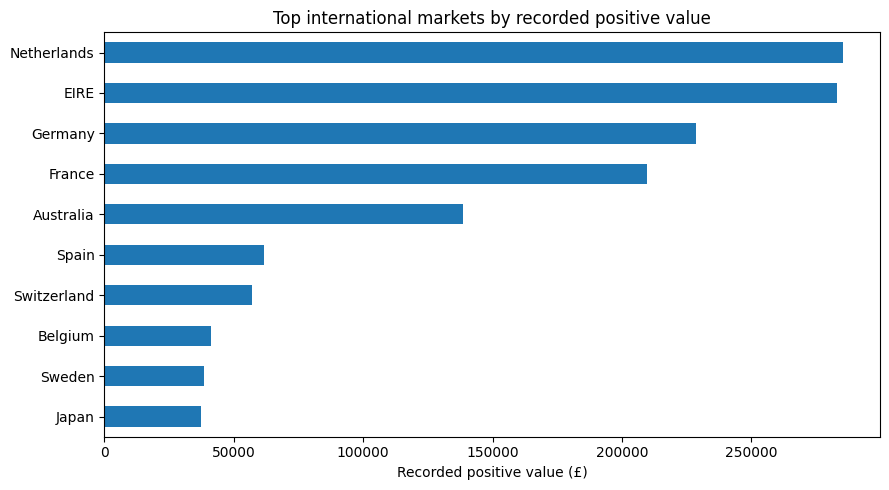

In [14]:
country_all = sales.groupby("Country").agg(
    Sales=("LineSales", "sum"),
    Invoices=("InvoiceNo", "nunique"),
)
display(country_all.sort_values("Sales", ascending=False).head(10))

country_known = identified.groupby("Country").agg(
    Sales=("LineSales", "sum"),
    Invoices=("InvoiceNo", "nunique"),
    Customers=("CustomerID", "nunique"),
)
country_known["SalesPerInvoice"] = (
    country_known["Sales"] / country_known["Invoices"]
)

display(
    country_known.loc[
        (country_known.index != "United Kingdom")
        & (country_known["Invoices"] >= 10)
    ].sort_values("SalesPerInvoice", ascending=False).head(10)
)

international = (
    country_all.drop(index="United Kingdom", errors="ignore")
    .nlargest(10, "Sales")
    .sort_values("Sales")
)

ax = international["Sales"].plot(
    kind="barh",
    figsize=(9, 5),
    title="Top international markets by recorded positive value",
)
ax.set_xlabel("Recorded positive value (£)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Geographic findings

The United Kingdom records £9,001,744.09, approximately 84.6% of all
recorded positive value. The Netherlands is the largest international
market by recorded positive value at £285,446.34.

Within the identified-customer comparison restricted to international
countries with at least ten positive-sales invoices, the Netherlands
has the highest recorded value per invoice: £3,036.66 across 94 invoices.

Only nine identified customers contribute to the Netherlands figure.
Further assessment should examine customer concentration, repeat purchasing,
margins, and delivery costs before recommending market expansion.

## Q8. Which invoice lines merit investigation?

An IQR flag identifies values far from the middle of a distribution. It is
not evidence of an error. Show high quantities and high unit prices alongside
their descriptions and invoice identifiers; retain plausible bulk orders.

In [15]:
def upper_iqr_bound(series):
    q1, q3 = series.quantile([0.25, 0.75])
    return q3 + 1.5 * (q3 - q1)

quantity_bound = upper_iqr_bound(sales["Quantity"])
price_bound = upper_iqr_bound(sales["UnitPrice"])

print(f"Quantity IQR upper bound: {quantity_bound:,.2f}")
print(f"Quantity-flagged lines: "
      f"{(sales['Quantity'] > quantity_bound).sum():,}")
print(f"Unit-price IQR upper bound: £{price_bound:,.2f}")
print(f"Price-flagged lines: "
      f"{(sales['UnitPrice'] > price_bound).sum():,}")

inspection_cols = [
    "InvoiceNo", "StockCode", "Description_clean",
    "Quantity", "UnitPrice", "LineSales", "Country",
    "IsNonMerchandise",
]
display(sales.nlargest(10, "Quantity")[inspection_cols])
display(sales.nlargest(10, "UnitPrice")[inspection_cols])

Quantity IQR upper bound: 26.00
Quantity-flagged lines: 27,111
Unit-price IQR upper bound: £8.45
Price-flagged lines: 37,827


,InvoiceNo,StockCode,Description_clean,Quantity,UnitPrice,LineSales,Country,IsNonMerchandise
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,United Kingdom,False
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom,False
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,United Kingdom,False
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,United Kingdom,False
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,United Kingdom,False
270885,560599,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,3186,0.06,191.16,United Kingdom,False
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom,False
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom,False
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,United Kingdom,False
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,United Kingdom,False


,InvoiceNo,StockCode,Description_clean,Quantity,UnitPrice,LineSales,Country,IsNonMerchandise
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,United Kingdom,True
299982,A563185,B,ADJUST BAD DEBT,1,11062.06,11062.06,United Kingdom,True
173382,551697,POST,POSTAGE,1,8142.75,8142.75,United Kingdom,True
297723,562955,DOT,DOTCOM POSTAGE,1,4505.17,4505.17,United Kingdom,True
268028,560373,M,MANUAL,1,4287.63,4287.63,United Kingdom,True
422351,573077,M,MANUAL,1,4161.06,4161.06,France,True
422376,573080,M,MANUAL,1,4161.06,4161.06,France,True
406406,571751,M,MANUAL,1,3949.32,3949.32,Singapore,True
374542,569382,M,MANUAL,1,3155.95,3155.95,United Kingdom,True
347948,567353,M,MANUAL,1,2653.95,2653.95,Hong Kong,True


In [16]:
# Examine the two largest positive-quantity lines alongside matching
# negative-quantity entries in the deduplicated source.
largest_lines = sales.nlargest(2, "Quantity")

for _, sale in largest_lines.iterrows():
    same_customer = (
        base["CustomerID"].isna()
        if pd.isna(sale["CustomerID"])
        else base["CustomerID"].eq(sale["CustomerID"])
    )

    possible_reversals = base.loc[
        base["StockCode"].eq(sale["StockCode"])
        & same_customer
        & base["Quantity"].eq(-sale["Quantity"])
        & np.isclose(base["UnitPrice"], sale["UnitPrice"])
    ].copy()

    print(f"\nPositive invoice: {sale['InvoiceNo']}")
    display(
        sale[[
            "InvoiceNo", "InvoiceDate", "StockCode",
            "Description_clean", "CustomerID",
            "Quantity", "UnitPrice", "LineSales"
        ]].to_frame("value")
    )

    print("Matching negative entries — candidates for reversal:")
    display(
        possible_reversals[[
            "InvoiceNo", "InvoiceDate", "StockCode",
            "Description_clean", "CustomerID",
            "Quantity", "UnitPrice"
        ]]
    )


Positive invoice: 581483


,value
InvoiceNo,581483
InvoiceDate,2011-12-09 09:15:00
StockCode,23843
Description_clean,"PAPER CRAFT , LITTLE BIRDIE"
CustomerID,16446.0
Quantity,80995
UnitPrice,2.08
LineSales,168469.6


Matching negative entries — candidates for reversal:


,InvoiceNo,InvoiceDate,StockCode,Description_clean,CustomerID,Quantity,UnitPrice
540422,C581484,2011-12-09 09:27:00,23843,"PAPER CRAFT , LITTLE BIRDIE",16446.0,-80995,2.08



Positive invoice: 541431


,value
InvoiceNo,541431
InvoiceDate,2011-01-18 10:01:00
StockCode,23166
Description_clean,MEDIUM CERAMIC TOP STORAGE JAR
CustomerID,12346.0
Quantity,74215
UnitPrice,1.04
LineSales,77183.6


Matching negative entries — candidates for reversal:


,InvoiceNo,InvoiceDate,StockCode,Description_clean,CustomerID,Quantity,UnitPrice
61624,C541433,2011-01-18 10:17:00,23166,MEDIUM CERAMIC TOP STORAGE JAR,12346.0,-74215,1.04


### Large-line investigation


The two largest positive-quantity lines have a combined recorded value of £245,653.20 — approximately **2.31%** of all recorded positive value. They materially affect product rankings and identified-customer spending.

The check above searched for negative entries sharing the same customer, stock code, and unit price, with an opposite quantity. **Both lines have matching negative counterparts:**

- **Invoice 581483** (PAPER CRAFT, LITTLE BIRDIE; stock 23843; customer 16446; 80,995 units @ £2.08) is matched by a reversal of **-80,995 units at £2.08** on invoice **C581484**, dated **2011-12-09 at 09:27** — 12 minutes after the original entry.
- **Invoice 541431** (MEDIUM CERAMIC TOP STORAGE JAR; stock 23166; customer 12346; 74,215 units @ £1.04) is matched by a reversal of **-74,215 units at £1.04** on invoice **C541433**, dated **2011-01-18 at 10:17** — 16 minutes after the original entry.

In both cases the reversal is recorded minutes apart from the original, with identical quantity and unit price under the same customer and stock code. This strongly indicates the lines were **cancelled or corrected within the same transaction session** rather than representing genuine sales, so they should not be treated as evidence of sustained product demand or customer value.

The positive-value analysis retains these lines under its stated definition. This investigation belongs in the portfolio because it shows the result was questioned and traced to its source — including a check for matching negative entries — rather than immediately recommending more stock on the strength of a striking figure.

## Extended analysis: merchandise sales versus units

Median-based quadrants describe relative position within this dataset.
“High sales / low units” does not prove a product is premium or profitable.
“Low sales / low units” does not justify discontinuation without margin,
inventory, product age, and strategic context.

In [17]:
sales_mid = products["Sales"].median()
units_mid = products["Units"].median()

products["RelativePosition"] = np.select(
    [
        (products["Sales"] >= sales_mid)
        & (products["Units"] >= units_mid),
        (products["Sales"] >= sales_mid)
        & (products["Units"] < units_mid),
        (products["Sales"] < sales_mid)
        & (products["Units"] >= units_mid),
    ],
    [
        "High sales / high units",
        "High sales / low units",
        "Low sales / high units",
    ],
    default="Low sales / low units",
)

display(
    products.groupby("RelativePosition")
    .agg(
        Products=("StockCode", "count"),
        Sales=("Sales", "sum"),
        Units=("Units", "sum"),
    )
)

,Products,Sales,Units
RelativePosition,,,
High sales / high units,1668,9389339.670,5110092
High sales / low units,290,466820.000,65850
Low sales / high units,290,124679.520,258715
Low sales / low units,1667,274179.993,126907


## Findings and proposed business checks

| Observed finding | Implication to investigate | Proposed next step |
|---|---|---|
| November had the highest full-month sales and more invoices than October | Capacity may need to handle more orders in a similar period | Review stock availability and fulfilment records before setting inventory targets |
| A high-value customer segment contributes a large share of identified-customer sales | Losing several such customers could materially affect sales | Review repeat ordering and retention for those accounts |
| Some merchandise codes have low sales, units, and invoice frequency | They may warrant a range review | Check margin, age, stock holding cost, and strategic role before any removal |
| The Netherlands shows high sales per identified-customer invoice | Its order pattern deserves further study | Examine customer concentration, margins, logistics, and repeat orders |
| Two exceptionally large positive lines materially affect product and customer rankings | A headline result may reflect a reversal or exceptional event rather than recurring demand | Review matching negative entries before using these lines for inventory or account prioritisation |

## Limitations

- The source contains invoice lines, not an explicit order-line identifier.
  Exact-row deduplication is an assumption.
- Returns and cancellations were separated, so positive-sales totals are not
  net sales.
- CustomerID is missing for many lines; customer findings describe only
  identified customers.
- Revenue is not profit; product margin and inventory cost are unavailable.
- Descriptions and administrative entries require classification judgment.
- December 2011 ends on December 9, making its monthly total incomplete.
- The period cannot establish multi-year seasonality or causal explanations.
- Positive-value records include separately classified charges and accounting
  entries. Merchandise-only results use a narrower population.
- Exceptionally large positive lines may have matching negative entries;
  gross rankings do not automatically establish sustained demand.

In [18]:

OUTPUT_DIR = Path('..', 'Task-2-PowerBI-Dashboard-for-Ecommerce-EDA')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sales.to_csv(OUTPUT_DIR / "positive_sales.csv", index=False)
merchandise.to_csv(OUTPUT_DIR / "named_merchandise_sales.csv", index=False)
products.to_csv(OUTPUT_DIR / "product_summary.csv", index=False)
customers.reset_index().to_csv(
    OUTPUT_DIR / "identified_customer_summary.csv", index=False
)
monthly.reset_index().assign(
    YearMonth=lambda x: x["YearMonth"].astype(str)
).to_csv(OUTPUT_DIR / "monthly_summary.csv", index=False)

print("Positive-sales lines:", f"{len(sales):,}")
print("Named-merchandise lines:", f"{len(merchandise):,}")
print(
    "Recorded positive line value:",
    f"£{sales['LineSales'].sum():,.2f}"
)
print("Named-merchandise sales:", f"£{merchandise['LineSales'].sum():,.2f}")
print("Exports saved in:", OUTPUT_DIR)

Positive-sales lines: 524,878
Named-merchandise lines: 522,714
Recorded positive line value: £10,642,110.80
Named-merchandise sales: £10,255,019.18
Exports saved in: ..\Task-2-PowerBI-Dashboard-for-Ecommerce-EDA
